# Machine Learning

The objective of this notebook is to develop predictive machine learning models capable of estimating hospital length of stay using patient demographic and admission information.

Predicting hospital length of stay has important operational applications including:

- hospital bed management
- staffing requirements
- resource allocation
- patient flow optimization
- capacity planning

Three supervised machine learning algorithms will be developed and compared:

1. Linear Regression
2. Random Forest Regressor
3. Gradient Boosting Regressor

Each model will be evaluated using identical training and testing datasets to ensure a fair comparison.

# 2. Modeling Strategy

This project follows a supervised machine learning workflow.

Target Variable

- Length of Stay (days)

Prediction Type

Regression

Evaluation Metrics

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

The dataset will first be divided into training and testing subsets.

A preprocessing pipeline will automatically:

- impute missing values,
- encode categorical variables,
- scale numerical variables where appropriate.

The same preprocessing steps will be applied consistently to every machine learning model.

This approach reduces data leakage and improves reproducibility.

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



In [140]:
from pathlib import Path

df = pd.read_csv(
    Path.home() / "Data Science Projects" / "Healthcare-Demand-Forecasting" / "data" / "processed" / "processed_patient_data.csv"
)

In [141]:
df

,subject_id,gender,anchor_age,anchor_year,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,...,race,hospital_expire_flag,Length_of_Stay,admission_year,admission_month,admission_week,day_of_week,week_num,week_of_month,admission_hour
0,10004235,M,47,2196,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,...,BLACK/CAPE VERDEAN,0,8.975000,2196,2,2,Wednesday,4,fourth,14
1,10009628,M,58,2153,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,...,HISPANIC/LATINO - PUERTO RICAN,0,7.841667,2153,9,0,Monday,3,third,17
2,10018081,M,79,2133,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,...,WHITE,0,5.731250,2134,8,2,Wednesday,3,third,2
3,10006053,M,52,2111,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,URGENT,TRANSFER FROM HOSPITAL,DIED,...,UNKNOWN,1,1.736806,2111,11,4,Friday,2,second,23
4,10031404,F,82,2113,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,URGENT,TRANSFER FROM HOSPITAL,HOME,...,WHITE,0,2.090972,2113,8,4,Friday,1,first,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270,10038992,M,70,2185,24745425,2187-07-29 01:05:00,2187-08-03 17:02:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,...,WHITE,0,5.664583,2187,7,6,Sunday,5,fifth,1
271,10008287,F,43,2145,22168393,2145-09-28 01:17:00,2145-10-02 13:35:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME HEALTH CARE,...,WHITE,0,4.512500,2145,9,1,Tuesday,4,fourth,1
272,10022880,M,66,2177,27708593,2177-03-12 07:15:00,2177-03-19 14:25:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME,...,WHITE,0,7.298611,2177,3,2,Wednesday,2,second,7
273,10004457,M,65,2140,23251352,2141-12-17 11:00:00,2141-12-21 15:56:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,REHAB,...,OTHER,0,4.205556,2141,12,6,Sunday,3,third,11


# Prediction Problem

The objective of this project is to predict hospital length of stay.

Length of stay is measured as the number of days between hospital admission and discharge.

Predicting this variable can assist hospitals with:

- capacity planning
- patient flow
- staffing
- operational efficiency

Length of stay is a continuous variable, making this a regression problem.

In [142]:
target = "Length_of_Stay"

In [143]:
x = df
x

,subject_id,gender,anchor_age,anchor_year,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,...,race,hospital_expire_flag,Length_of_Stay,admission_year,admission_month,admission_week,day_of_week,week_num,week_of_month,admission_hour
0,10004235,M,47,2196,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,...,BLACK/CAPE VERDEAN,0,8.975000,2196,2,2,Wednesday,4,fourth,14
1,10009628,M,58,2153,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,...,HISPANIC/LATINO - PUERTO RICAN,0,7.841667,2153,9,0,Monday,3,third,17
2,10018081,M,79,2133,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,...,WHITE,0,5.731250,2134,8,2,Wednesday,3,third,2
3,10006053,M,52,2111,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,URGENT,TRANSFER FROM HOSPITAL,DIED,...,UNKNOWN,1,1.736806,2111,11,4,Friday,2,second,23
4,10031404,F,82,2113,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,URGENT,TRANSFER FROM HOSPITAL,HOME,...,WHITE,0,2.090972,2113,8,4,Friday,1,first,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270,10038992,M,70,2185,24745425,2187-07-29 01:05:00,2187-08-03 17:02:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,...,WHITE,0,5.664583,2187,7,6,Sunday,5,fifth,1
271,10008287,F,43,2145,22168393,2145-09-28 01:17:00,2145-10-02 13:35:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME HEALTH CARE,...,WHITE,0,4.512500,2145,9,1,Tuesday,4,fourth,1
272,10022880,M,66,2177,27708593,2177-03-12 07:15:00,2177-03-19 14:25:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME,...,WHITE,0,7.298611,2177,3,2,Wednesday,2,second,7
273,10004457,M,65,2140,23251352,2141-12-17 11:00:00,2141-12-21 15:56:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,REHAB,...,OTHER,0,4.205556,2141,12,6,Sunday,3,third,11


In [144]:
x = df.drop(columns=[target])
y = df[target]

In [145]:
x.head()

,subject_id,gender,anchor_age,anchor_year,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,...,marital_status,race,hospital_expire_flag,admission_year,admission_month,admission_week,day_of_week,week_num,week_of_month,admission_hour
0,10004235,M,47,2196,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,...,SINGLE,BLACK/CAPE VERDEAN,0,2196,2,2,Wednesday,4,fourth,14
1,10009628,M,58,2153,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,...,MARRIED,HISPANIC/LATINO - PUERTO RICAN,0,2153,9,0,Monday,3,third,17
2,10018081,M,79,2133,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,...,MARRIED,WHITE,0,2134,8,2,Wednesday,3,third,2
3,10006053,M,52,2111,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,URGENT,TRANSFER FROM HOSPITAL,DIED,...,NaN,UNKNOWN,1,2111,11,4,Friday,2,second,23
4,10031404,F,82,2113,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,URGENT,TRANSFER FROM HOSPITAL,HOME,...,WIDOWED,WHITE,0,2113,8,4,Friday,1,first,18


In [146]:
y.head()

0    8.975000
1    7.841667
2    5.731250
3    1.736806
4    2.090972
Name: Length_of_Stay, dtype: float64

# Exploratory Check Before Modeling

Before training machine learning models, the dataset is inspected to verify that:

- missing values have been handled,
- feature types are appropriate,
- target variable distribution is reasonable.

In [147]:
x.isnull().sum()

subject_id               0
gender                   0
anchor_age               0
anchor_year              0
hadm_id                  0
admittime                0
dischtime                0
admission_type           0
admission_location       0
discharge_location      42
insurance                0
language                 0
marital_status          12
race                     0
hospital_expire_flag     0
admission_year           0
admission_month          0
admission_week           0
day_of_week              0
week_num                 0
week_of_month            0
admission_hour           0
dtype: int64

Text(0, 0.5, 'Frequency')

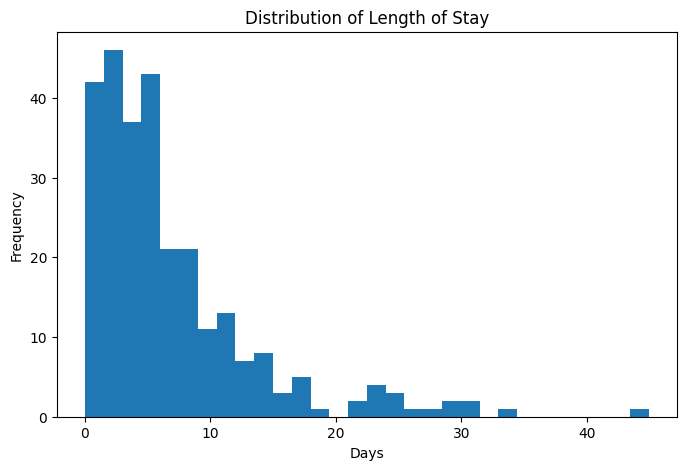

In [148]:
plt.figure(figsize=(8,5))
plt.hist(
    y, 
    bins=30
)

plt.title("Distribution of Length of Stay")
plt.xlabel("Days")
plt.ylabel("Frequency")


In [149]:
X_train, X_test, y_train, y_test = train_test_split(
    x, 
    y,
    test_size=0.20,
    random_state=42
)




In [150]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(220, 22)
(55, 22)
(220,)
(55,)


## Why an 80/20 Split? 

The dataset is divided into training and testing subsets. The training dataset is used to fit machine learning models. The testing dataset is held aside until evaluation. This ensures that model performance is measured on previously unseen observations. 

In [151]:
X_train

,subject_id,gender,anchor_age,anchor_year,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,...,marital_status,race,hospital_expire_flag,admission_year,admission_month,admission_week,day_of_week,week_num,week_of_month,admission_hour
10,10037861,M,77,2115,24256866,2115-10-09 20:28:00,2115-10-18 16:50:00,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,...,MARRIED,UNKNOWN,0,2115,10,2,Wednesday,2,second,20
260,10039831,F,57,2115,26924951,2115-12-28 07:15:00,2116-01-02 14:34:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME HEALTH CARE,...,MARRIED,UNABLE TO OBTAIN,0,2115,12,5,Saturday,4,fourth,7
267,10025612,M,82,2125,23403708,2125-09-25 07:15:00,2125-10-03 12:24:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME HEALTH CARE,...,MARRIED,WHITE,0,2125,9,1,Tuesday,4,fourth,7
33,10002930,F,48,2193,22733922,2198-04-22 16:17:00,2198-05-04 13:20:00,URGENT,INTERNAL TRANSFER TO OR FROM PSYCH,HOME,...,SINGLE,BLACK/AFRICAN AMERICAN,0,2198,4,6,Sunday,4,fourth,16
222,10039708,F,46,2138,29488258,2144-01-19 12:07:00,2144-01-21 21:20:00,OBSERVATION ADMIT,WALK-IN/SELF REFERRAL,HOME,...,SINGLE,BLACK/AFRICAN AMERICAN,0,2144,1,6,Sunday,3,third,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,10012853,F,91,2175,22896692,2176-08-11 15:17:00,2176-08-11 17:35:00,EU OBSERVATION,EMERGENCY ROOM,NaN,...,WIDOWED,BLACK/AFRICAN AMERICAN,0,2176,8,6,Sunday,2,second,15
71,10032725,F,38,2143,20611640,2143-03-22 04:59:00,2143-03-25 13:00:00,EW EMER.,EMERGENCY ROOM,HOSPICE,...,SINGLE,BLACK/AFRICAN AMERICAN,0,2143,3,4,Friday,4,fourth,4
106,10026406,M,45,2129,25260176,2129-01-03 15:55:00,2129-01-05 14:10:00,EW EMER.,EMERGENCY ROOM,AGAINST ADVICE,...,DIVORCED,WHITE,0,2129,1,0,Monday,1,first,15
270,10038992,M,70,2185,24745425,2187-07-29 01:05:00,2187-08-03 17:02:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,...,MARRIED,WHITE,0,2187,7,6,Sunday,5,fifth,1


In [152]:
numeric_features = [
    "anchor_age",
    "admission_month",
    "admission_hour"
]

categorical_features = [
    "gender",
    "admission_type",
    "admission_location",
    "insurance",
    "language",
    "marital_status",
    "race",
    "day_of_week"
]


In [153]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False, # to bypass encoder defaulting to sparse matrix
                drop="first" # apparently, for one-hot encoding the drop="first" gets rid of the redundant column, if not, starts dividing by zero and get warnings in model prediction
            )
        )
    ]
)




In [154]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

preprocessor.set_output(transform="pandas")

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['anchor_age', 'admission_month',
                                  'admission_hour']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'admission_type',
                                  'admission_location', 'insurance', 'language',
                                  'marital_status', 'race', 'day_of_week'])])

## Dummy Regressor

In [155]:
from sklearn.dummy import DummyRegressor

baseline_model = DummyRegressor(
    strategy="mean"
)

baseline_model.fit(
    X_train,
    y_train
)


DummyRegressor()

In [156]:
baseline_predictions = baseline_model.predict(
    X_test
)


In [157]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print(f"Baseline MAE: {baseline_mae:.3f}")
print(f"Baseline RMSE: {baseline_rmse:.3f}")
print(f"Baseline R\u00B2: {baseline_r2:.3f}")

Baseline MAE: 4.865
Baseline RMSE: 6.634
Baseline R²: -0.006


# Linear Regression

Linear Regression serves as the first predictive model. Although relatively simple, it provides an interpretable baseline capable of identifying linear relationships between patient characteristics and hospital length of stay. The model is combined with the preprocessing pipeline to ensure consistent handling of missing values, categorical variables, and numerical scaling. 

In [158]:
X_train

,subject_id,gender,anchor_age,anchor_year,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,...,marital_status,race,hospital_expire_flag,admission_year,admission_month,admission_week,day_of_week,week_num,week_of_month,admission_hour
10,10037861,M,77,2115,24256866,2115-10-09 20:28:00,2115-10-18 16:50:00,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,...,MARRIED,UNKNOWN,0,2115,10,2,Wednesday,2,second,20
260,10039831,F,57,2115,26924951,2115-12-28 07:15:00,2116-01-02 14:34:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME HEALTH CARE,...,MARRIED,UNABLE TO OBTAIN,0,2115,12,5,Saturday,4,fourth,7
267,10025612,M,82,2125,23403708,2125-09-25 07:15:00,2125-10-03 12:24:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,HOME HEALTH CARE,...,MARRIED,WHITE,0,2125,9,1,Tuesday,4,fourth,7
33,10002930,F,48,2193,22733922,2198-04-22 16:17:00,2198-05-04 13:20:00,URGENT,INTERNAL TRANSFER TO OR FROM PSYCH,HOME,...,SINGLE,BLACK/AFRICAN AMERICAN,0,2198,4,6,Sunday,4,fourth,16
222,10039708,F,46,2138,29488258,2144-01-19 12:07:00,2144-01-21 21:20:00,OBSERVATION ADMIT,WALK-IN/SELF REFERRAL,HOME,...,SINGLE,BLACK/AFRICAN AMERICAN,0,2144,1,6,Sunday,3,third,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,10012853,F,91,2175,22896692,2176-08-11 15:17:00,2176-08-11 17:35:00,EU OBSERVATION,EMERGENCY ROOM,NaN,...,WIDOWED,BLACK/AFRICAN AMERICAN,0,2176,8,6,Sunday,2,second,15
71,10032725,F,38,2143,20611640,2143-03-22 04:59:00,2143-03-25 13:00:00,EW EMER.,EMERGENCY ROOM,HOSPICE,...,SINGLE,BLACK/AFRICAN AMERICAN,0,2143,3,4,Friday,4,fourth,4
106,10026406,M,45,2129,25260176,2129-01-03 15:55:00,2129-01-05 14:10:00,EW EMER.,EMERGENCY ROOM,AGAINST ADVICE,...,DIVORCED,WHITE,0,2129,1,0,Monday,1,first,15
270,10038992,M,70,2185,24745425,2187-07-29 01:05:00,2187-08-03 17:02:00,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,...,MARRIED,WHITE,0,2187,7,6,Sunday,5,fifth,1


In [159]:
linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

linear_model.fit(
    X_train,
    y_train
)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['anchor_age',
                                                   'admission_month',
                                                   'admission_hour']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'admission_type',
                                                   'admission_location',
                                                   'insurance', 'language',
                                                   'marital_status', 'race',
                                                   'day_of_week'])])),
                ('model', LinearRegression())])

In [172]:
linear_predictions = linear_model.predict(X_test)

/Users/frank/DataLearning/dsenve/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/frank/DataLearning/dsenve/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/frank/DataLearning/dsenve/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [173]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression")
print(f"MAE: {linear_mae:.3f}")
print(f"RMSE: {linear_rmse:.3f}")
print(f"R\u00b2: {linear_r2:.3f}")

Linear Regression
MAE: 5.513
RMSE: 7.548
R²: -0.303
